# Korrektur

- Viel Erfolg!

### Bewertung

#### _/20 Punkte

----

In [3]:
from pandas.core.interchange.dataframe_protocol import DataFrame

'''import standard libraries'''
import numpy as np                       # mathematical methods
from matplotlib import pyplot as plt     # plotting methods within notebook
from scipy import stats                  # lots of statistical methods
%matplotlib inline
import statsmodels.api as sm             # contains OLS
import statsmodels.formula.api as smf    # ... with Patsy
import patsy 
import pandas as pd                      # convenient data handling

# Übungsaufgaben 12 - Lineare Modelle

#### Bitte lösen sie die Aufgaben 
- innerhalb dieses Notebooks 
- welches Sie bitte umbenennen in `A12_IHRNAME.ipynb` (IHRNAME passend ersetzen)

#### Danke!

### Hinweise
Wie gehabt; insbesondere:
#### Beantworten Sie die Fragen hier nachvollziehbar. Begründen, erklären, kommentieren Sie ... 
Alle Aufgaben sind mit aus der Vorlesung bekannten, in `scipy`, `pandas` und `statsmodels` implementierten Methoden lösbar.

---

# Aufgabe 1) Ende der Kirschsaison

### Gibt es eine Zunahme des Wurmbefalls über die Jahre?

In [13]:
years = ['2019', '2022', '2023', '2024', '2025']
w_19 = [12, 10, 11, 16, 14, 11]          # early worms 2019
w_22 = [15, 15, 18, 11, 11, 11, 13]      # worms 2022
w_23 = [18, 9, 17, 13, 15, 9, 17, 12]    # worms 2023
w_24 = [20, 12, 14, 17, 13]              # worms 2024
w_25 = [16, 19, 19]                      # worms 2025
# make dataframe from lists
data = {
    'years': [2019]*len(w_19) + [2022]*len(w_22) + [2023]*len(w_23) + [2024]*len(w_24) + [2025]*len(w_25),
    'worms': w_19 + w_22 + w_23 + w_24 + w_25
}
df_1 = pd.DataFrame(data)
print(df_1.head())

   years  worms
0   2019     12
1   2019     10
2   2019     11
3   2019     16
4   2019     14


Slope:      0.7097
p-Value:    0.018160


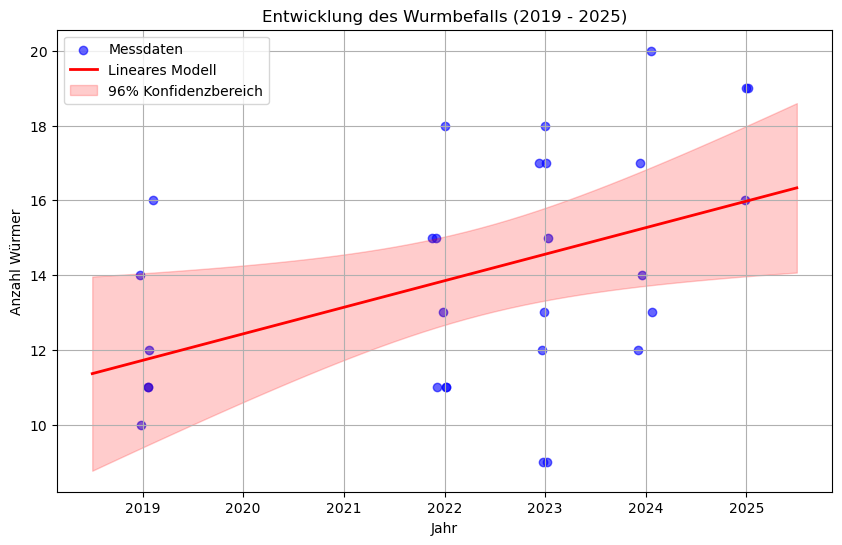

In [15]:
# fit linear model
fit = smf.ols(formula = "worms ~ years", data = df_1).fit()

# extract relevant values
slope_1 = fit.params["years"]
p_value_1 = fit.pvalues["years"]

# print results
print(f"Slope:      {slope_1:.4f}")
print(f"p-Value:    {p_value_1:4f}")

# visualise model and fit
# prep data
x_grid_1 = np.linspace(df_1["years"].min() - 0.5, df_1["years"].max() + 0.5)
pred_df_1 = pd.DataFrame({"years" : x_grid_1})
predictions_1 = fit.get_prediction(pred_df_1)
pred_frame_1 = predictions_1.summary_frame(alpha = 0.04)

# plot
plt.figure(figsize = (10, 6))
jitter_1 = np.random.normal(0, 0.05, size = len(df_1))
# data
plt.scatter(df_1["years"] + jitter_1, df_1["worms"], color = "blue", alpha = 0.6, label = "Messdaten")
# model (regression straight)
plt.plot(x_grid_1, pred_frame_1["mean"], color = "red", linewidth = 2, label = "Lineares Modell")
# confidence
plt.fill_between(x_grid_1, pred_frame_1["mean_ci_lower"], pred_frame_1["mean_ci_upper"], color = "red", alpha = 0.2, label = "96% Konfidenzbereich")
plt.title("Entwicklung des Wurmbefalls (2019 - 2025)")
plt.xlabel("Jahr")
plt.ylabel("Anzahl Würmer")
plt.legend()
plt.grid()
plt.show()


Ja, es gibt einen signifikanten Anstieg des Wurmbefalls in den Zeitraum 2019 bis 2025. Die Steigung über die Jahre ist mit 0.71 positiv, wie auch in der Grafik zu sehen ist. Das Model sagt eine Zunahme von 0.71 Würmern pro Jahr voraus. Der zugehörige p-Wert liegt mit 0.018 im Ablehnungsbereich (für alpha = 4%). Damit ist der Einfluss der Zeit statistisch signifikant.

$\color{green}{3 \text{ Punkte}}$

## Korrektur

Punkte

---

## Datensatz
http://www.statsci.org/data/general/sleep.html

# Aufgabe 2) Intelligenz?
## Hat der Mensch unter all den Säugetieren (im Datensatz) ein außergewöhlich großes Gehirn?

Eine naive Vorstellung: Die Genetik mit sehr vielen kleinen Beiträgen trägt während der Embryonalentwicklung zum (als zufällig streuend angenommenen) Zellwachstum des Gehirns eines Säugetiers bei.

Benutzen Sie den möglichst umfangreichen Datensatz. Irrtumswahrscheinlickeit $\alpha=4\%$

### a) Bestimmen Sie das 94%-Konfidenzintervall
für (lediglich) das gemessene Gehirngewicht eines allgemeinen Säugetiers aus dem oben genannten Datensatz.

In [19]:
# import data
df_2 = pd.read_csv("animals.txt", sep = "\t")
brain_weights_2 = df_2["BrainWt"].dropna()

# calc
n_2 = len(brain_weights_2)
mean_bw_2 = np.mean(brain_weights_2)
std_bw_2 = np.std(brain_weights_2, ddof = 1)

# critical t-value
alpha_2 = 0.06 # for 94% confidence intervals
t_crit_2 = stats.t.ppf(1 - alpha_2 / 2, df = n_2 - 1)

# prediction intervals
margin_2 = t_crit_2 * std_bw_2 * np.sqrt(1 + 1 / n_2)
lower_2 = mean_bw_2 - margin_2
upper_2 = mean_bw_2 + margin_2

print(f"Mittelwert:             {mean_bw_2:.2f} g")
print(f"Standardabweichung:     {std_bw_2:.2f} g")
print(f"94% Konfidenzintervall: [{lower_2:.2f}, {upper_2:.2f}]")

Mittelwert:             283.13 g
Standardabweichung:     930.28 g
94% Konfidenzintervall: [-1513.99, 2080.26]


Die bestimmte Konfidenzintervalle (94%) unter der Annahme einer Normalverteilung liegen, bei -1515g und 2080g. Natürlich können die Gewichte nicht negativ sein.

### b) Ist das Gehirn eines Menschen demnach außergewöhnlich?

Nein, das Gehirn des Menschen (1320g) ist nicht außer gewöhnlich. Das Gewicht liegt deutlich innerhalb des Konfidenzintervalls. Somit weicht es nicht signifikant von der Erwartung für ein Säugetier ab. Dies liegt ein wenig an den Daten, welche wir uns anschauen. Die Spannweite bei Säugetieren ist extrem breit, wodurch die Intervalle etwas ungenauer sind.

### c) Begründen Sie, 
warum die Lösung dieser Fragestellung auf diesem Weg problematisch ist. Es gibt mehrere Aspekte zu beachten. (2 P.)

Ein problematischer Punkt wäre die Abhängigkeit vom Körpergewicht. Denn das Gehirngewicht wird oft größer mit zunehmenden Körpergewicht. Es ist nicht sinnvoll, das Gehirngewicht, direkt zwischen Maus < Mensch < Elefant zu vergleichen. Durch die große Disparität im Datensatz entsteht eine große Varianz. Viel interessanter wäre die relative Gehirngröße.

Des Weiteren ist es eine extrem schiefe Verteilung, also nicht normalverteilt. Es gibt viele Tiere mit kleinem Gehirngewicht und wenige große. Dadurch entsteht eine große Standardabweichung, wodurch der berechnete Intervall in den unlogischen Bereich geht (-1500).

$\color{green}{4 \text{ Punkte}}$

## Korrektur

Punkte

---

# Aufgabe 3) ein besserer Test
zweiter Anlauf: Hat der Mensch ein außergewöhlich großes Gehirn?

Als ein möglicher Ausweg von einem der Probleme in Aufgabe 2) betrachten Sie nun nur den Teildatensatz mit 10 vergleichbar schweren Säugetieren. 

(Hinweise zu Pandas am Ende)

### Ihr Test-Ergebnis nun?
Argumentieren Sie wieder mit Hilfe des 94%-Konfidenzintervalls

Vergleichen Sie mit dem Ergebnis aus Aufgabe 2)

In [32]:
# get reference human
human = df_2[df_2["Species"] == "Man"].iloc[0]
human_bodyw = human["BodyWt"]
human_brainw = human["BrainWt"]

# 10 most similar mammals
others = df_2[df_2["Species"] != "Man"].copy()
others["diff"] = (others["BodyWt"] - human_bodyw).abs()
others_sorted = others.sort_values("diff").head(10)
print("Vergleichsgruppe:")
print(others_sorted[["Species", "BodyWt", "BrainWt"]])

# calc
brain_vals = others_sorted["BrainWt"]
n_3 = len(brain_vals)
mean_3 = np.mean(brain_vals)
std_3 = np.std(brain_vals)

# critical t-value
alpha_3 = 0.06
t_crit_3 = stats.t.ppf(1 - alpha_3 / 2, df = n_3 - 1)

# prediction intervals
margin_3 = t_crit_3 * std_3 * np.sqrt(1 + 1 / n_3)
lower_3 = mean_3 - margin_3
upper_3 = mean_3 + margin_3

print(f"\nMittelwert:             {mean_3:.2f} g")
print(f"Standardabweichung:     {std_3:.2f} g")
print(f"94% Konfidenzintervall: [{lower_3:.2f}, {upper_3:.2f}]")

Vergleichsgruppe:
           Species  BodyWt  BrainWt
19  Giantarmadillo   60.00     81.0
53           Sheep   55.50    175.0
9       Chimpanzee   52.16    440.0
24        Grayseal   85.00    325.0
25        Graywolf   36.33    119.5
30        Kangaroo   35.00     56.0
21            Goat   27.66    115.0
29          Jaguar  100.00    157.0
52         Roedeer   14.83     98.2
5           Baboon   10.55    179.5

Mittelwert:             174.62 g
Standardabweichung:     113.42 g
94% Konfidenzintervall: [-81.18, 430.42]


Im Vergleich des Gehirngewicht des Menschen (1320 g) mit den 10 Tieren, welche die niedrigste Differenz im Körpergewicht zum Menschen haben, kann man ein anderes Resultat als in 2) erkennen. Das Gehirngewicht liegt deutlich außerhalb des Konfidenzintervalls [-81.18, 430.42]. Im Vergleich zur Aufgabe 2), wo der Mensch im  starken Rauschen durch die besonders schweren Tiere unterging, ist in diesem lokalisierten Vergleich der MEnsch ein signifikanter Ausreißer.

$\color{green}{3 \text{ Punkte}}$

## Korrektur

Punkte

---

# Aufgabe 4) Test mit linearem Modell
Um Größenordnungen innerhalb der Säugetiergewichte zu vergleichen, logarithmieren wir die Gewichte.

Verwenden Sie diese Daten und Ergebnisse in Aufgabe 5) dann einfach weiter.

### a) Fit
Fitten Sie bestmöglich ein lineares Modell *log(Gehirngewicht) in Abhängigkeit log(Körpergewicht)* an die Daten an.
- Nutzen Sie (indirekt) *patsy* aus
- Geben Sie die Ergebnisübersicht `summary` an

In [35]:
# import data
df_4 = pd.read_csv("animals.txt", sep = "\t")

# log waits
df_4["log_BrainWt"] = np.log(df_4["BrainWt"])
df_4["log_BodyWt"] = np.log(df_4["BodyWt"])

# fit
model_log_4 = smf.ols(formula = "log_BrainWt ~ log_BodyWt", data = df_4).fit()

print(model_log_4.summary())


                            OLS Regression Results                            
Dep. Variable:            log_BrainWt   R-squared:                       0.921
Model:                            OLS   Adj. R-squared:                  0.919
Method:                 Least Squares   F-statistic:                     697.4
Date:                Thu, 22 Jan 2026   Prob (F-statistic):           9.84e-35
Time:                        22:23:42   Log-Likelihood:                -64.336
No. Observations:                  62   AIC:                             132.7
Df Residuals:                      60   BIC:                             136.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.1348      0.096     22.227      0.0

### b) Beschreiben Sie wichtige Erkenntnisse 
aus den erhaltenen Modell-Parametern der Ergebnistabelle.

Inwieweit weicht das Ergebnis von Ihrer Erwartung ab? ...

Das R-squared mit etwa 0.92 zeigt, dass das Modell sehr gut passt. Das Körpergewicht erklärt über 90% der Varianz im Gehirngewicht. Außerdem zeigt der log_BodyWt coef mit 0.75, dass bei 1% Körpergewichtzuwachs, dass Gehirngewicht um 0.75% steigt. Außerdem sind beide p-Werte äußerst signifikant. Insgesamt wäre schon die Erwartung, dass mit ansteigendem Körpergewicht, auch das Gehirngewicht wächst. Aber, dass die Wachstumsraten so unterschiedlich sind, ist sehr interessant.

### c) Interpolation und Ausreißer?
Wie schwer sollte nun gemäß dieses linearen Modells das Gehirn eines 80kg schweren Menschen (in Gramm, mit 4% Unsicherheit) sein?

Vergleichen Sie mit realen Daten (Gehirngewicht=1,4kg https://faculty.washington.edu/chudler/facts.html).

Ist der Mensch demnach ein Ausreißer in der Gruppe der Säugetiere (mit statistischer Begründung)?

In [39]:
# pred for human
human_bodyweight = 80
pred_input = pd.DataFrame({"log_BodyWt": [np.log(human_bodyweight)]})
pred_obj = model_log_4.get_prediction(pred_input)
pred_frame_4c = pred_obj.summary_frame(alpha = 0.06)

# prediction intervals
log_mean_4c = pred_frame_4c["mean"][0]
log_lower_4c = pred_frame_4c["mean_ci_lower"][0]
log_upper_4c = pred_frame_4c["mean_ci_upper"][0]

# transform back from log
pred_val_4c = np.exp(log_mean_4c)
lower_4c = np.exp(log_lower_4c)
upper_4c = np.exp(log_upper_4c)

print(f"Modellvorhersage:             {pred_val_4c:.2f} g")
print(f"94% Konfidenzintervall: [{lower_4c:.2f}, {upper_4c:.2f}]")

Modellvorhersage:             227.85 g
94% Konfidenzintervall: [179.77, 288.79]


Das Modell würde für ein menschliches Körpergewicht von 80 kg ein Gehirngewicht von etwa 228 g vorhersagen. Dabei liegt das Konfidenzintervall für Säugetiere in dem Gewichtsbereich bei [179.77, 288.79]. Das reale gewicht von etwa 1400 g liegt deutlich über halb dieser Vorhersage und Konfidenzintervalls. Auch unter Berücksichtigung des allgemeinen Trends ist das menschliche Gehirn ein deutlicher Ausreißer nach oben.

### d) Extrapolation
Was sagt das Modell für kleinste (Schweinsnasenfledermaus; 1,7g) und größte (Blauwal; 200 Tonnen) Säugetiere voraus? Verwundert Sie das Ergebnis?

In [41]:
# pred for bat and whale
bat_bodyweight = 1.7 / 1000
pred_input_bat = pd.DataFrame({"log_BodyWt": [np.log(bat_bodyweight)]})
pred_obj_bat = model_log_4.get_prediction(pred_input_bat)
pred_frame_bat = pred_obj_bat.summary_frame(alpha = 0.06)
whale_bodyweight = 200 * 1000
pred_input_whale = pd.DataFrame({"log_BodyWt": [np.log(whale_bodyweight)]})
pred_obj_whale = model_log_4.get_prediction(pred_input_whale)
pred_frame_whale = pred_obj_whale.summary_frame(alpha = 0.06)

# prediction intervals
log_mean_bat = pred_frame_bat["mean"][0]
log_lower_bat = pred_frame_bat["mean_ci_lower"][0]
log_upper_bat = pred_frame_bat["mean_ci_upper"][0]
log_mean_whale = pred_frame_whale["mean"][0]
log_lower_whale = pred_frame_whale["mean_ci_lower"][0]
log_upper_whale = pred_frame_whale["mean_ci_upper"][0]

# transform back from log
pred_val_bat = np.exp(log_mean_bat)
lower_bat = np.exp(log_lower_bat)
upper_bat = np.exp(log_upper_bat)
pred_val_whale = np.exp(log_mean_whale)
lower_whale = np.exp(log_lower_whale)
upper_whale = np.exp(log_upper_whale)

print(f"Modellvorhersage Fledermaus:    {pred_val_bat:.2f} g")
print(f"94% Konfidenzintervall:         [{lower_bat:.2f}, {upper_bat:.2f}]")
print(f"Modellvorhersage Wal:           {pred_val_whale:.2f} g")
print(f"94% Konfidenzintervall:         [{lower_whale:.2f}, {upper_whale:.2f}]")

Modellvorhersage Fledermaus:    0.07 g
94% Konfidenzintervall:         [0.04, 0.11]
Modellvorhersage Wal:           81627.53 g
94% Konfidenzintervall:         [44057.76, 151234.51]


| Tier                    | Körpergewicht (kg) | Vorhergesagtes Gehirngewicht (g) |
|-------------------------|--------------------|----------------------------------|
| Schweinsnasenfledermaus | 0.0017 (1,7 g)     | 0.07                             |
| Blauwal                 | 200,000,000        | 81,627.53 (81.62 kg)             |

Bei der Fledermaus scheint es eine realistische Größenordnung zu sein. Das vorhergesagte Gehirngewicht würde etwa 4% des Körpergewichtes einnehmen, was nicht komplett undenkbar ist. Tatsächlich ist das Gehirn etwas doppelt so schwer. Bei dem Blauwal hingegen scheint es ein Recht großes Gewicht sein. Dies bestätigt sich auch, wenn man das tatsächliche Gewicht von 6 bis 7 kg nachschlägt. Hier überschätzt das Modell das Gewicht deutlich.

$\color{green}{6 \text{ Punkte}}$

## Korrektur

Punkte

---

# Aufgabe 5) Lineares Modell anschaulich

### a) Erstellen Sie die passende Graphik
zu Aufgabe 4): *log(Gehirngewicht) in Abhängigkeit log(Körpergewicht)*. Recyclen Sie einfach ihr dortiges Ergebnis.
- Extrahieren Sie dazu die in Aufgabe 4a) berechneten Parameter (siehe Hinweise am Ende)
- Tragen Sie die Modellvorhersage mitsamt 94% Konfidenzbereich ein
- Tragen Sie den 94% Konfidenzbereich für die Datenvorhersage ein
(3 P.)

### b) Interpretieren Sie das graphische Ergebnis im Hinblick auf den Menschen
Nehmen Sie Bezug zu Aufgaben 3) und 4)

### [Bonus] c) Zeichnen Sie den Wal und die Fledermaus ein
siehe Aufgabe 4d) und vergleichen Sie Modell- mit realen Daten.

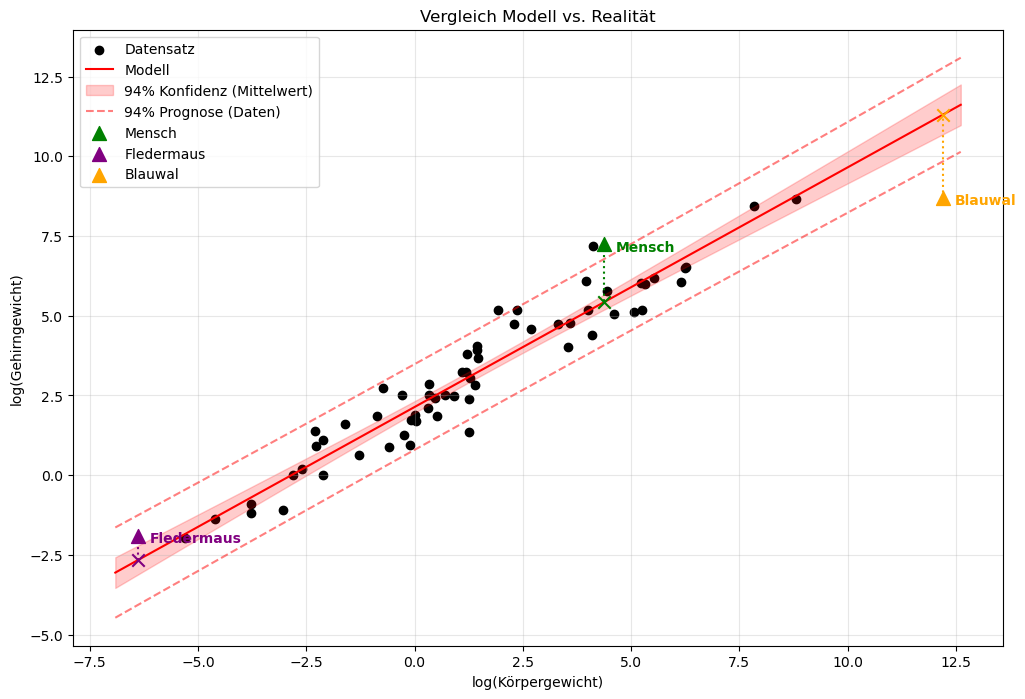

In [61]:
x_grid_5 = np.linspace(np.log(0.001), np.log(300000), 100)
pred_input_5 = pd.DataFrame({"log_BodyWt": x_grid_5})

pred_summary_5 = model_log_4.get_prediction(pred_input_5).summary_frame(alpha=0.06)

# add animals
special_animals = [
    {"name": "Mensch",      "body": 80.0,   "brain": 1400.0, "color": "green",  "marker": "^"},
    {"name": "Fledermaus",  "body": 0.0017, "brain": 0.15,   "color": "purple", "marker": "^"},
    {"name": "Blauwal",     "body": 200000.0, "brain": 6000.0, "color": "orange", "marker": "^"}
]

# plot
plt.figure(figsize=(12, 8))
# all animal data
plt.scatter(df_4["log_BodyWt"], df_4["log_BrainWt"], color="black", label="Datensatz")
# modell + intervalls
plt.plot(x_grid_5, pred_summary_5["mean"], "r-", label="Modell")
plt.fill_between(x_grid_5, pred_summary_5["mean_ci_lower"], pred_summary_5["mean_ci_upper"], color="red", alpha=0.2, label="94% Konfidenz (Mittelwert)")
plt.plot(x_grid_5, pred_summary_5["obs_ci_lower"], "r--", alpha=0.5, label="94% Prognose (Daten)")
plt.plot(x_grid_5, pred_summary_5["obs_ci_upper"], "r--", alpha=0.5)
# add special animals
for animal in special_animals:
    log_body = np.log(animal["body"])
    log_brain_real = np.log(animal["brain"])
    plt.scatter(log_body, log_brain_real, color=animal["color"], s=100, marker=animal["marker"], label=f"{animal["name"]}", zorder=5)
    log_brain_pred = model_log_4.predict(pd.DataFrame({"log_BodyWt": [log_body]})).iloc[0]
    plt.scatter(log_body, log_brain_pred, color=animal["color"], marker="x", s=80, zorder=5)
    plt.plot([log_body, log_body], [log_brain_real, log_brain_pred], color=animal["color"], linestyle=":", linewidth=1.5)
    plt.annotate(animal["name"], (log_body, log_brain_real), xytext=(8, -5), textcoords="offset points", color=animal["color"], fontweight="bold")

plt.title("Vergleich Modell vs. Realität")
plt.xlabel("log(Körpergewicht)")
plt.ylabel("log(Gehirngewicht)")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.show()

Der Mensch liegt weit oberhalb der Regressionsgeraden und außerhalb des Prognosenintervalls. Im globalen Vergleich liegt der Mensch deutlich außerhalb des Konfidenzintervalls. Dies ist ein ähnliches Ergebnis, wie in Aufgabe 4. IM Vergleich mit Tieren in der gleichen Gewichtsklasse sieht man, dass der Mensch deutlich über den anderen liegt (der weiße Punkt links neben dem grünen Dreieck ist der Mensch in dem original Datensatz). Dies ist das gleiche Ergebnis, wie in Aufgabe 3. Bei der Fledermaus ist das Modell Recht akkurat. Bei Mensch und Blauwal liegt das Modell deutlich daneben. Dies liegt eventuell daran, dass es viele Tiere im Bereich 1 bis 40 kg gibt, weshalb das Modell besser an diese kleinen Werte gefittet ist.

$\color{green}{4+2 \text{ Punkte}}$

## Korrektur

Punkte

---

# Bonus

Sollten Ihnen noch Übungspunkte zur Klausurzulassung oder zum Überschreiten der Bonusschwelle fehlen, können Sie (eine der) Übungsaufgaben "Vorhersageintervalle" aus den Folien "Lineare Modelle" lösen. 

$\color{green}{3+\dots \text{ Punkte}}$

## Korrektur

Punkte

---


### Hinweise zu Python / pandas

    np.log10()                                        # Logarithm base 10; inverse of 10**a
    xgrid = np.linspace(np.min(x), np.max(x), 100)    # quasi continuous plotting range
    plt.fill_between(xgrid, y2+PI, y2-PI, color='None', linestyle='--')
    plt.fill_between(xgrid, y2+CI, y2-CI, color='#b9cfe7', edgecolor='')
    fit.fittedvalues
    fit.conf_int()[0][0]                              # [0=lower][0=1st parameter]
    fit.df_<TAB>
    # visibility by plot order or transparency: plt.plot( ..., alpha=0.5, ...) 

https://pandas.pydata.org/pandas-docs/stable/user_guide/cookbook.html

- Building Criteria
- Selection
- Sorting

---

### Glückwunsch, alle Aufgaben fertig!